# Week 1 — Volatility Surfaces: From Theory to the Trading Desk

**Goal of this notebook.** You already know SDEs/PDEs, Itô's lemma, the Euler scheme and the
basic Black–Scholes story. This week we close the gap between that theory and what *actually sits
on a derivatives desk*: the **volatility surface**.

We will, for a real name (**AAPL**):

1. Build a **risk-free discount curve** from US Treasury data (FRED, with a yfinance fallback).
2. Measure **realized volatility** from the stock's own history and model it with **GARCH(1,1)**.
3. Recap **Black–Scholes** and **implied volatility** (the inversion problem).
4. Pull the **live AAPL option chain** and build the **market implied-vol surface** in 3D —
   shown side-by-side with the **call-price surface** it was inverted from.
5. Compare **realized vs implied** vol (the *variance risk premium*).
6. Contrast the market surface with the **flat Black–Scholes** surface (constant-vol assumption).
7. Calibrate **SABR** per expiry slice (the desk standard for interpolating smiles).
8. Build a **Heston** surface from illustrative parameters (stochastic vol; with a note on calibration).

> **Three lenses on "volatility" you must keep separate.** *Realized* vol is backward-looking
> (what the stock actually did). *Implied* vol is forward-looking and risk-neutral (what option
> prices imply). *Model* vol (Heston/SABR/GARCH) is our attempt to describe or forecast the first two.

## 0. Setup

Standard scientific Python stack. `arch` gives us GARCH, `fredapi` pulls Treasury data, `plotly`
gives interactive (rotatable) 3D surfaces — important since the shape of a surface is the whole point.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.optimize import brentq, least_squares
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yfinance as yf

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TICKER = "AAPL"
TODAY = pd.Timestamp.today().normalize()
N_DAYS_YEAR = 252  # trading days per year, for annualising vol

print(f"Today: {TODAY.date()}  |  Underlying: {TICKER}")

Today: 2026-06-15  |  Underlying: AAPL


## 1. The risk-free discount curve

Every option price is a **discounted risk-neutral expectation**:
$$ C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\big[(S_T-K)^+\big]. $$
To price/compare options of different maturities we need $r$ as a function of maturity $T$ — the
**term structure** of rates. Banks bootstrap this from OIS/SOFR; for a learning notebook the US
Treasury par curve is a perfectly good proxy.

We pull constant-maturity Treasury yields from **FRED** (`DGS3MO … DGS30`). If you haven't added a
free FRED key yet (`.env` → `FRED_API_KEY=...`), we fall back to yfinance Treasury-yield indices
(`^IRX, ^FVX, ^TNX, ^TYX`). We then linearly interpolate the **continuously-compounded** rate in $T$.

> *Simplification:* we treat the quoted par yields as zero rates. A desk would bootstrap true zero
> rates; the difference is small at this horizon and doesn't change the surface story.

In [2]:
def load_treasury_curve():
    '''Return (tenors_in_years, cc_rates) for the US risk-free curve.

    Tries FRED first (needs FRED_API_KEY in .env); falls back to yfinance yield indices.
    Rates are returned as continuously-compounded decimals (e.g. 0.045 = 4.5%).
    '''
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))  # walk up from cwd to find .env in project root
    key = os.environ.get("FRED_API_KEY")

    # FRED constant-maturity Treasury series -> {tenor_years: series_code}
    fred_map = {0.25: "DGS3MO", 0.5: "DGS6MO", 1: "DGS1", 2: "DGS2",
                3: "DGS3", 5: "DGS5", 7: "DGS7", 10: "DGS10", 20: "DGS20", 30: "DGS30"}

    tenors, yields, source = [], [], None
    if key:
        try:
            from fredapi import Fred
            fred = Fred(api_key=key)
            for T, code in fred_map.items():
                s = fred.get_series(code).dropna()
                if len(s):
                    tenors.append(T)
                    yields.append(s.iloc[-1] / 100.0)  # FRED quotes percent
            source = "FRED"
        except Exception as e:
            print("FRED failed, falling back to yfinance:", e)

    if source is None:  # yfinance fallback: ^IRX=13wk, ^FVX=5y, ^TNX=10y, ^TYX=30y
        yf_map = {0.25: "^IRX", 5: "^FVX", 10: "^TNX", 30: "^TYX"}
        for T, sym in yf_map.items():
            h = yf.Ticker(sym).history(period="5d")["Close"].dropna()
            if len(h):
                tenors.append(T)
                yields.append(h.iloc[-1] / 100.0)
        source = "yfinance"

    order = np.argsort(tenors)
    tenors = np.array(tenors)[order]
    # par yield -> continuously compounded: r_cc = ln(1 + y)
    cc = np.log1p(np.array(yields)[order])
    print(f"Risk-free curve source: {source}")
    return tenors, cc


CURVE_T, CURVE_R = load_treasury_curve()


def risk_free_rate(T):
    '''Continuously-compounded zero rate at maturity T (years), linearly interpolated.'''
    T = np.asarray(T, dtype=float)
    return np.interp(T, CURVE_T, CURVE_R)


def discount_factor(T):
    '''P(0,T) = exp(-r(T) * T).'''
    return np.exp(-risk_free_rate(T) * np.asarray(T, dtype=float))


pd.DataFrame({"tenor_yrs": CURVE_T, "rate_%": CURVE_R * 100}).round(3)

Risk-free curve source: FRED


,tenor_yrs,rate_%
0,0.2500,3.7100
1,0.5000,3.7490
2,1.0000,3.7870
3,2.0000,4.0090
4,3.0000,4.0370
5,5.0000,4.1240
6,7.0000,4.2480
7,10.0000,4.3830
8,20.0000,4.8600
9,30.0000,4.8500


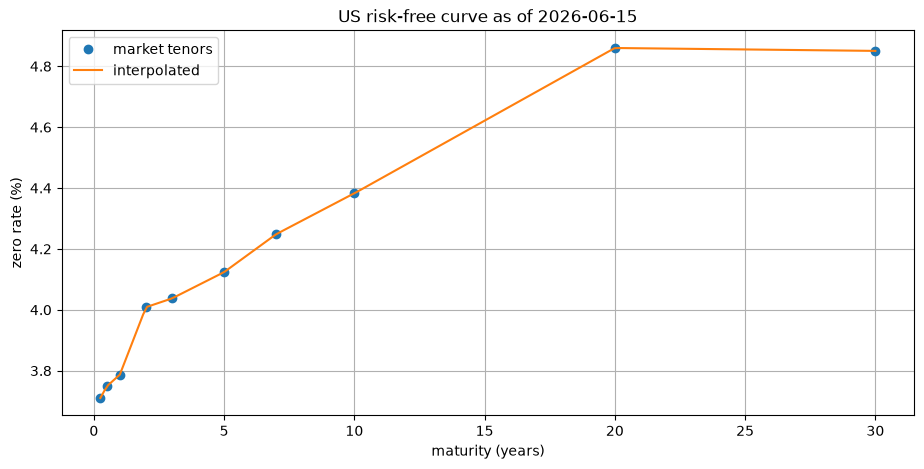

In [3]:
# Visualise the curve we will discount with.
grid = np.linspace(CURVE_T.min(), CURVE_T.max(), 200)
plt.plot(CURVE_T, CURVE_R * 100, "o", label="market tenors")
plt.plot(grid, risk_free_rate(grid) * 100, "-", label="interpolated")
plt.xlabel("maturity (years)"); plt.ylabel("zero rate (%)")
plt.title(f"US risk-free curve as of {TODAY.date()}"); plt.legend(); plt.show()

## 2. The underlying and *realized* volatility

Realized (a.k.a. historical) volatility is the standard deviation of **log returns**, annualised.
With daily closes $S_t$ and log returns $r_t=\ln(S_t/S_{t-1})$:
$$ \sigma_{\text{realized}} = \sqrt{N}\;\operatorname{std}(r_t), \qquad N = 252. $$

This is **backward-looking** — it tells you what the stock *did*, not what it *will* do. Notice
the rolling estimate is far from constant: volatility **clusters** (calm and stormy regimes). That
single observation is what motivates GARCH next, and is also why a single flat Black–Scholes $\sigma$
can never match the market.

Spot S0 = 296.42
Full-sample realized vol: 25.9%


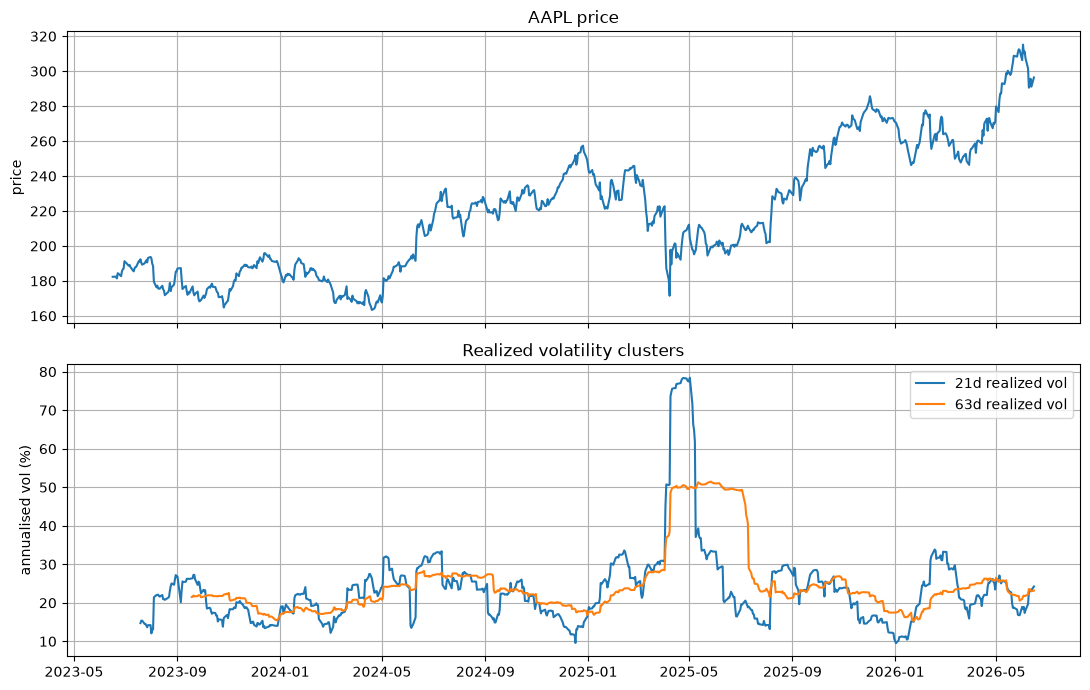

In [4]:
spot_hist = yf.Ticker(TICKER).history(period="3y", auto_adjust=True)
px = spot_hist["Close"].dropna()
S0 = float(px.iloc[-1])
log_ret = np.log(px / px.shift(1)).dropna()

# Rolling 21-day (~1 month) realized vol, annualised, plus a slower 63-day window.
rv_21 = log_ret.rolling(21).std() * np.sqrt(N_DAYS_YEAR)
rv_63 = log_ret.rolling(63).std() * np.sqrt(N_DAYS_YEAR)

print(f"Spot S0 = {S0:.2f}")
print(f"Full-sample realized vol: {log_ret.std()*np.sqrt(N_DAYS_YEAR):.1%}")

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(px.index, px.values); ax[0].set_ylabel("price"); ax[0].set_title(f"{TICKER} price")
ax[1].plot(rv_21.index, rv_21 * 100, label="21d realized vol")
ax[1].plot(rv_63.index, rv_63 * 100, label="63d realized vol")
ax[1].set_ylabel("annualised vol (%)"); ax[1].set_title("Realized volatility clusters")
ax[1].legend(); plt.tight_layout(); plt.show()

## 3. GARCH(1,1) — modelling and forecasting realized vol

Realized vol clusters, so tomorrow's variance depends on today's. **GARCH(1,1)** captures exactly
this with a mean-reverting variance recursion:
$$ \sigma_t^2 = \omega + \alpha\,\epsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2 . $$

- $\alpha$ — reaction to the last shock (how much a big move spikes vol).
- $\beta$ — persistence (how slowly vol decays back).
- $\alpha+\beta$ close to 1 ⇒ very persistent vol; long-run variance is $\omega/(1-\alpha-\beta)$.

GARCH gives a **forecast term structure of volatility** — mean-reverting toward the long-run level —
which we'll later hold up against the implied-vol term structure. (We fit returns in percent, the
`arch` convention, for numerical stability.)

mu         0.0689
omega      0.1820
alpha[1]   0.0708
beta[1]    0.8567
Name: params, dtype: float64

Persistence alpha+beta = 0.927
GARCH long-run annualised vol = 25.2%


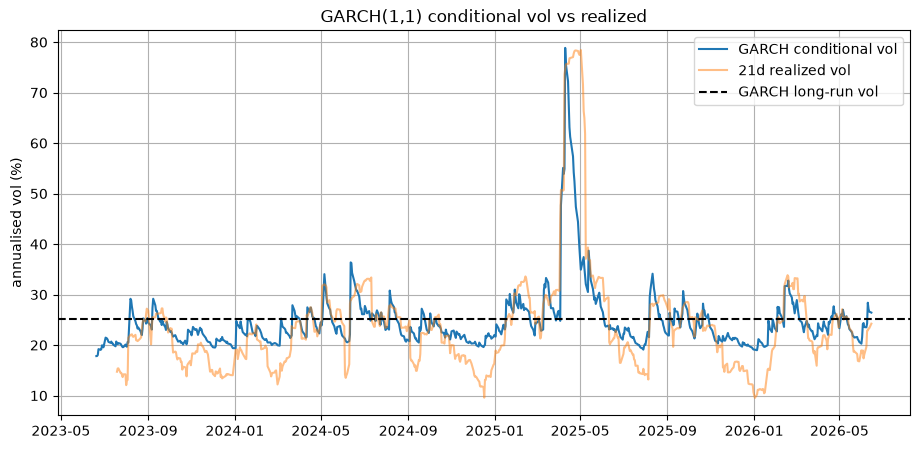

In [5]:
from arch import arch_model

ret_pct = log_ret * 100.0  # arch convention: returns in percent
am = arch_model(ret_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
garch = am.fit(disp="off")
print(garch.params)

# Annualised conditional (in-sample) vol from the fitted model.
cond_vol_ann = garch.conditional_volatility / 100.0 * np.sqrt(N_DAYS_YEAR)
cond_vol_ann = pd.Series(cond_vol_ann, index=log_ret.index)

# Long-run (unconditional) annualised vol implied by the parameters.
w, a, b = garch.params["omega"], garch.params["alpha[1]"], garch.params["beta[1]"]
lr_var_daily = w / (1 - a - b) / (100.0 ** 2)
lr_vol_ann = np.sqrt(lr_var_daily * N_DAYS_YEAR)
print(f"\nPersistence alpha+beta = {a+b:.3f}")
print(f"GARCH long-run annualised vol = {lr_vol_ann:.1%}")

plt.plot(cond_vol_ann.index, cond_vol_ann * 100, label="GARCH conditional vol")
plt.plot(rv_21.index, rv_21 * 100, alpha=0.5, label="21d realized vol")
plt.axhline(lr_vol_ann * 100, ls="--", color="k", label="GARCH long-run vol")
plt.ylabel("annualised vol (%)"); plt.title("GARCH(1,1) conditional vol vs realized")
plt.legend(); plt.show()

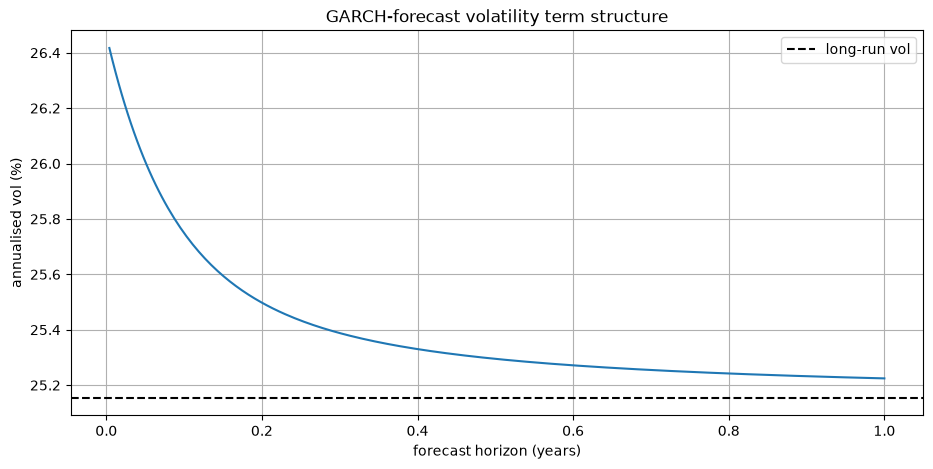

In [6]:
# Forecast the vol TERM STRUCTURE: expected annualised vol over the next h trading days.
H = 252
fc = garch.forecast(horizon=H, reindex=False)
var_path_daily = fc.variance.values[-1] / (100.0 ** 2)        # daily variance per horizon step
# Term vol to horizon h = sqrt(mean daily variance over 1..h), annualised.
cum_var = np.cumsum(var_path_daily)
term_vol_ann = np.sqrt(cum_var / np.arange(1, H + 1) * N_DAYS_YEAR)
horizon_years = np.arange(1, H + 1) / N_DAYS_YEAR

plt.plot(horizon_years, term_vol_ann * 100)
plt.axhline(lr_vol_ann * 100, ls="--", color="k", label="long-run vol")
plt.xlabel("forecast horizon (years)"); plt.ylabel("annualised vol (%)")
plt.title("GARCH-forecast volatility term structure"); plt.legend(); plt.show()

GARCH_TERM = pd.Series(term_vol_ann, index=horizon_years)  # reused in Section 6

## 4. Black–Scholes and the *implied volatility* inversion

Black–Scholes price of a European call/put on a stock with continuous dividend yield $q$:
$$ d_1=\frac{\ln(S/K)+(r-q+\tfrac12\sigma^2)T}{\sigma\sqrt T},\quad d_2=d_1-\sigma\sqrt T,$$
$$ C = Se^{-qT}N(d_1)-Ke^{-rT}N(d_2),\qquad P = Ke^{-rT}N(-d_2)-Se^{-qT}N(-d_1).$$

**Implied volatility** flips the formula around: given a *market price*, find the single $\sigma$ that
reproduces it. BS is monotonic in $\sigma$ (vega $>0$), so the inverse is unique — we solve it with a
1-D root finder (Brent). The market quotes options in vol, not price, precisely because IV is the
"common language" that normalises across strikes and maturities.

In [7]:
def bs_price(S, K, T, r, sigma, q=0.0, kind="call"):
    '''Black–Scholes price for a European option (vectorised over arrays).'''
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    sqT = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / sqT
    d2 = d1 - sqT
    if kind == "call":
        return S * np.exp(-q * T) * st.norm.cdf(d1) - K * np.exp(-r * T) * st.norm.cdf(d2)
    return K * np.exp(-r * T) * st.norm.cdf(-d2) - S * np.exp(-q * T) * st.norm.cdf(-d1)


def bs_vega(S, K, T, r, sigma, q=0.0):
    '''dPrice/dSigma — same for call and put.'''
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * st.norm.pdf(d1) * np.sqrt(T)


def implied_vol(price, S, K, T, r, q=0.0, kind="call"):
    '''Invert BS for sigma via Brent. Returns NaN if no arbitrage-free solution in [1e-4, 5].'''
    intrinsic = (max(S * np.exp(-q * T) - K * np.exp(-r * T), 0.0) if kind == "call"
                 else max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0))
    if price < intrinsic - 1e-8 or price <= 0:
        return np.nan
    f = lambda sig: bs_price(S, K, T, r, sig, q, kind) - price
    try:
        return brentq(f, 1e-4, 5.0, maxiter=200)
    except ValueError:
        return np.nan


# Sanity check: price a call, then recover its vol.
_p = bs_price(100, 100, 1.0, 0.04, 0.25, kind="call")
print(f"BS call (S=K=100,T=1,r=4%,vol=25%) = {_p:.4f}")
print(f"Recovered implied vol = {implied_vol(_p, 100, 100, 1.0, 0.04):.4f}  (should be 0.25)")

BS call (S=K=100,T=1,r=4%,vol=25%) = 11.8370
Recovered implied vol = 0.2500  (should be 0.25)


## 5. The market implied-vol surface from the live AAPL chain

Now the real thing. We pull the live AAPL option chain across several expiries and turn raw quotes
into a clean implied-vol surface. The desk-grade hygiene steps:

1. **Mid price** = ½(bid+ask); drop zero-bid / crossed / illiquid quotes.
2. **Forward per expiry** $F = S e^{(r-q)T}$ (dividends matter for the moneyness axis).
3. **Use OTM options** — OTM puts for $K<F$, OTM calls for $K\ge F$. They're the liquid ones, and
   under put–call parity a call and put at the same strike share *one* implied vol, so OTM quotes
   give the cleanest smile.
4. Invert each quote to IV; express strikes as **moneyness** $K/S$ (in %) so maturities are comparable.

**Axes.** $x=$ moneyness $K/S$ (%), $y=$ time to maturity $T$, $z=$ implied vol. We then rebuild a
**call-price surface** with those same IVs and show the two side-by-side: the IV surface is just a
re-expression of the price surface that's easier to read.

In [8]:
tk = yf.Ticker(TICKER)

# Dividend yield for the forward (small for AAPL, but include it for correctness).
try:
    q_div = float(tk.info.get("dividendYield") or 0.0)
    # yfinance versions are inconsistent: some return a fraction (0.004), others a
    # percent (0.4 or even 37.0). A real single-stock yield is well under 5%, so any
    # value above that must be percent-quoted -> divide by 100.
    if q_div > 0.05:
        q_div /= 100.0
except Exception:
    q_div = 0.0
print(f"Dividend yield q = {q_div:.2%}")

# Choose a spread of expiries: skip the nearest (microstructure noise) then sample ~8 across the term.
all_exp = pd.to_datetime(tk.options)
all_exp = all_exp[all_exp > TODAY + pd.Timedelta(days=7)]
sel_exp = all_exp[np.linspace(0, len(all_exp) - 1, min(8, len(all_exp))).astype(int)]
print("Expiries used:", [d.date().isoformat() for d in sel_exp])

Dividend yield q = 0.36%
Expiries used: ['2026-06-24', '2026-07-02', '2026-07-24', '2026-09-18', '2026-12-18', '2027-03-19', '2027-12-17', '2028-12-15']


In [9]:
def build_iv_surface(expiries):
    '''Pull the chain for each expiry, clean it, and invert OTM quotes to implied vol.'''
    rows = []
    for exp in expiries:
        T = (exp - TODAY).days / 365.0
        if T <= 0:
            continue
        r = float(risk_free_rate(T))
        F = S0 * np.exp((r - q_div) * T)          # forward
        try:
            chain = tk.option_chain(exp.strftime("%Y-%m-%d"))
        except Exception:
            continue
        for kind, df in (("call", chain.calls), ("put", chain.puts)):
            d = df.copy()
            d["mid"] = (d["bid"] + d["ask"]) / 2.0
            # liquidity / sanity filters
            d = d[(d["bid"] > 0) & (d["ask"] > 0) & (d["ask"] >= d["bid"]) & (d["mid"] > 0.05)]
            # keep OTM only: OTM puts below the forward, OTM calls above it
            d = d[(d["strike"] >= F)] if kind == "call" else d[(d["strike"] < F)]
            for _, o in d.iterrows():
                iv = implied_vol(o["mid"], S0, o["strike"], T, r, q_div, kind)
                if np.isfinite(iv) and 0.01 < iv < 3.0:
                    rows.append(dict(expiry=exp, T=T, strike=o["strike"], kind=kind,
                                     mid=o["mid"], iv=iv, F=F,
                                     moneyness=o["strike"] / S0))
    return pd.DataFrame(rows)


surf = build_iv_surface(sel_exp)
# Restrict to a sensible moneyness band where quotes are trustworthy.
surf = surf[(surf["moneyness"] > 0.70) & (surf["moneyness"] < 1.30)].reset_index(drop=True)
print(f"Clean option points: {len(surf)}")
surf.head()

Clean option points: 220


,expiry,T,strike,kind,mid,iv,F,moneyness
0,2026-06-24,0.0247,297.5000,call,3.6500,0.2180,296.6650,1.0036
1,2026-06-24,0.0247,300.0000,call,2.5850,0.2161,296.6650,1.0121
2,2026-06-24,0.0247,302.5000,call,1.7100,0.2113,296.6650,1.0205
3,2026-06-24,0.0247,305.0000,call,1.1850,0.2157,296.6650,1.0289
4,2026-06-24,0.0247,307.5000,call,0.8000,0.2194,296.6650,1.0374


### 5a. The smile, one maturity at a time

Before the 3D view, look at single-expiry **slices**. BS would predict a flat horizontal line
(one vol for all strikes). The market instead shows a **skew/smirk**: deep OTM puts (downside crash
protection) trade at higher implied vol than OTM calls. This asymmetry *is* the equity vol skew.

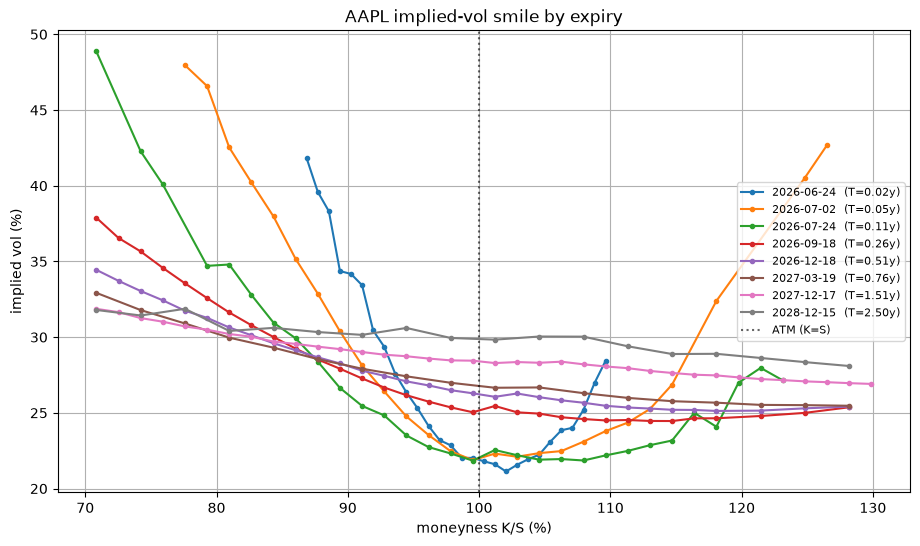

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
for exp, g in surf.groupby("expiry"):
    g = g.sort_values("moneyness")
    ax.plot(g["moneyness"] * 100, g["iv"] * 100, "o-", ms=3,
            label=f"{exp.date()}  (T={g['T'].iloc[0]:.2f}y)")
ax.axvline(100, color="k", ls=":", alpha=0.6, label="ATM (K=S)")
ax.set_xlabel("moneyness K/S (%)"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"{TICKER} implied-vol smile by expiry"); ax.legend(fontsize=8); plt.show()

### 5b. The 3D surfaces — implied vol vs the call prices it came from

We interpolate the scattered $(\text{moneyness}, T, \text{IV})$ points onto a regular grid and render
two surfaces side-by-side:

- **Left — implied-vol surface:** the desk's working object. Read the *skew* along moneyness and the
  *term structure* along $T$.
- **Right — call-price surface:** the BS call value rebuilt from those same IVs. Smooth and monotonic;
  the IV surface is just this object expressed in the "vol language" that makes the smile legible.

(Drag to rotate.)

In [11]:
def grid_surface(df, value, gm=40, gt=30):
    '''Interpolate scattered points onto a regular (moneyness, T) grid for plotting.'''
    mm = np.linspace(df["moneyness"].min(), df["moneyness"].max(), gm)
    tt = np.linspace(df["T"].min(), df["T"].max(), gt)
    MM, TT = np.meshgrid(mm, tt)
    ZZ = griddata((df["moneyness"], df["T"]), df[value], (MM, TT), method="linear")
    return MM, TT, ZZ


MM, TT, IV = grid_surface(surf, "iv")

# Rebuild a call-price surface from the SAME implied vols (per grid node).
rgrid = risk_free_rate(TT)
CALL = bs_price(S0, MM * S0, TT, rgrid, IV, q_div, kind="call")

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "surface"}, {"type": "surface"}]],
                    subplot_titles=("Implied-vol surface", "Call-price surface (same IVs)"))
fig.add_trace(go.Surface(x=MM * 100, y=TT, z=IV * 100, colorscale="Viridis", showscale=False), 1, 1)
fig.add_trace(go.Surface(x=MM * 100, y=TT, z=CALL, colorscale="Cividis", showscale=False), 1, 2)
fig.update_scenes(xaxis_title="moneyness %", yaxis_title="T (yrs)")
fig.layout.scene.zaxis.title = "IV %"; fig.layout.scene2.zaxis.title = "call $"
fig.update_layout(height=550, width=1000, title=f"{TICKER} market surfaces — {TODAY.date()}")
fig.show()

## 6. Realized vs implied — the variance risk premium

Pull the **ATM implied-vol term structure** (moneyness nearest 100% at each expiry) and overlay it on
the **GARCH realized-vol forecast** from Section 3. Almost always, **implied sits above realized**:
option *buyers* pay a premium for protection, so sellers earn the **variance risk premium**. The gap
is, in effect, the market's risk-adjusted price of future uncertainty — not a pure forecast.

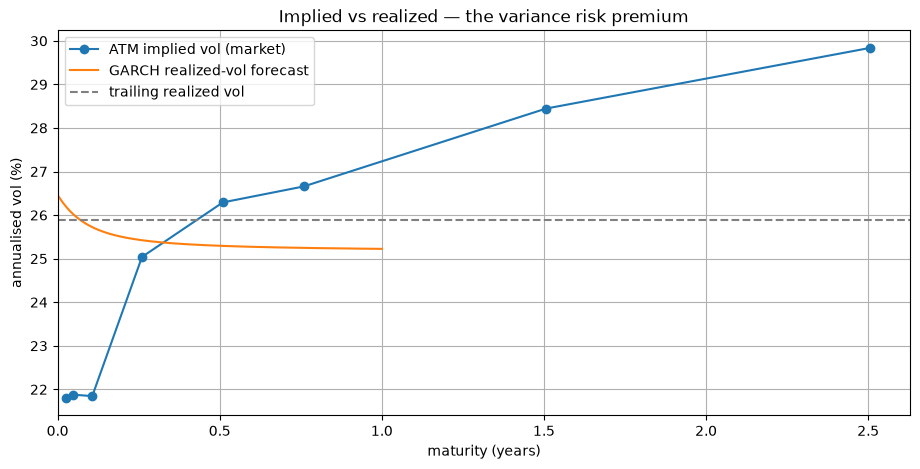

Mean ATM implied: 25.2% | trailing realized: 25.9%


In [12]:
# ATM implied vol per expiry = the point closest to moneyness 1.0.
atm = (surf.assign(dist=(surf["moneyness"] - 1.0).abs())
            .sort_values("dist").groupby("T", as_index=False).first()
            .sort_values("T"))

plt.plot(atm["T"], atm["iv"] * 100, "o-", label="ATM implied vol (market)")
plt.plot(GARCH_TERM.index, GARCH_TERM.values * 100, label="GARCH realized-vol forecast")
plt.axhline(log_ret.std() * np.sqrt(N_DAYS_YEAR) * 100, ls="--", color="grey",
            label="trailing realized vol")
plt.xlim(0, atm["T"].max() * 1.05)
plt.xlabel("maturity (years)"); plt.ylabel("annualised vol (%)")
plt.title("Implied vs realized — the variance risk premium"); plt.legend(); plt.show()

print("Mean ATM implied:", f"{atm['iv'].mean():.1%}",
      "| trailing realized:", f"{log_ret.std()*np.sqrt(N_DAYS_YEAR):.1%}")

## 7. Implied vs the flat Black–Scholes surface

Black–Scholes assumes **one constant $\sigma$** — i.e. a perfectly **flat** surface. Let's draw that
flat plane (at the ATM level) under the real market surface. The market's **skew** (tilt across
moneyness) and **term structure** (drift across $T$) are exactly the features a single BS number
*cannot* represent. This visual is the whole reason desks moved beyond constant-vol BS to local- and
stochastic-vol models.

In [13]:
flat_level = atm["iv"].mean()                 # single BS vol = average ATM
FLAT = np.full_like(IV, flat_level)

fig = go.Figure()
fig.add_trace(go.Surface(x=MM * 100, y=TT, z=IV * 100, colorscale="Viridis",
                         name="market", showscale=False, opacity=0.95))
fig.add_trace(go.Surface(x=MM * 100, y=TT, z=FLAT * 100, colorscale="Greys",
                         name="flat BS", showscale=False, opacity=0.5))
fig.update_layout(height=600, width=850,
                  title=f"Market IV surface (colour) vs flat BS plane at {flat_level:.1%}",
                  scene=dict(xaxis_title="moneyness %", yaxis_title="T (yrs)", zaxis_title="IV %"))
fig.show()

## 8. SABR — the desk standard for smile interpolation

SABR models the forward and its vol as coupled SDEs:
$$ dF = \alpha F^\beta\,dW_1,\qquad d\alpha = \nu\,\alpha\,dW_2,\qquad dW_1\,dW_2=\rho\,dt. $$

Its fame comes from **Hagan's closed-form approximation** for the implied vol $\sigma_{\text{SABR}}(K,F)$,
so calibrating a smile is a fast 3-parameter least-squares fit (we fix $\beta$):

- $\alpha$ — overall vol level (sets the ATM height).
- $\rho$ — spot/vol correlation ⇒ the **skew** (equities: $\rho<0$).
- $\nu$ — vol-of-vol ⇒ the **curvature/smile**.

We calibrate SABR **per expiry slice** (how desks actually use it), then assemble the fitted slices
into a smooth arbitrage-light surface.

In [14]:
def sabr_iv(F, K, T, alpha, beta, rho, nu):
    '''Hagan (2002) lognormal SABR implied vol approximation.'''
    F, K = float(F), float(K)
    if abs(F - K) < 1e-8:  # ATM limit
        term = ((1 - beta) ** 2 / 24 * alpha ** 2 / F ** (2 - 2 * beta)
                + rho * beta * nu * alpha / (4 * F ** (1 - beta))
                + (2 - 3 * rho ** 2) / 24 * nu ** 2)
        return alpha / F ** (1 - beta) * (1 + term * T)
    logFK = np.log(F / K)
    FKb = (F * K) ** ((1 - beta) / 2)
    z = nu / alpha * FKb * logFK
    xz = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    A = alpha / (FKb * (1 + (1 - beta) ** 2 / 24 * logFK ** 2
                        + (1 - beta) ** 4 / 1920 * logFK ** 4))
    B = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / FKb ** 2
             + rho * beta * nu * alpha / (4 * FKb)
             + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return A * (z / xz) * B


def calibrate_sabr_slice(strikes, ivs, F, T, beta=0.5):
    '''Least-squares fit (alpha, rho, nu) of one expiry smile; beta fixed.'''
    def resid(p):
        alpha, rho, nu = p
        model = np.array([sabr_iv(F, K, T, alpha, beta, rho, nu) for K in strikes])
        return model - ivs
    lb = np.array([1e-4, -0.999, 1e-4]); ub = np.array([100.0, 0.999, 10.0])
    p0 = np.clip([ivs.mean() * F ** (1 - beta), -0.3, 0.5], lb + 1e-6, ub - 1e-6)
    res = least_squares(resid, p0, bounds=(lb, ub), max_nfev=2000)
    return dict(alpha=res.x[0], beta=beta, rho=res.x[1], nu=res.x[2])


# Calibrate every expiry slice and print the fitted parameters.
sabr_params = {}
for (exp, T), g in surf.groupby(["expiry", "T"]):
    g = g.sort_values("strike")
    if len(g) < 4:
        continue
    sabr_params[T] = calibrate_sabr_slice(g["strike"].values, g["iv"].values, g["F"].iloc[0], T)

pd.DataFrame(sabr_params).T.rename_axis("T").round(3)

,alpha,beta,rho,nu
T,,,,
0.0247,3.4230,0.5000,-0.1600,4.9120
0.0466,3.3280,0.5000,-0.1250,3.8170
0.1068,3.4930,0.5000,-0.1860,2.3210
0.2603,4.2040,0.5000,-0.1920,1.1880
0.5096,4.4150,0.5000,-0.1490,0.8110
0.7589,4.5290,0.5000,-0.1090,0.6120
1.5068,4.8840,0.5000,0.0300,0.3380
2.5041,5.2550,0.5000,0.9990,0.0370


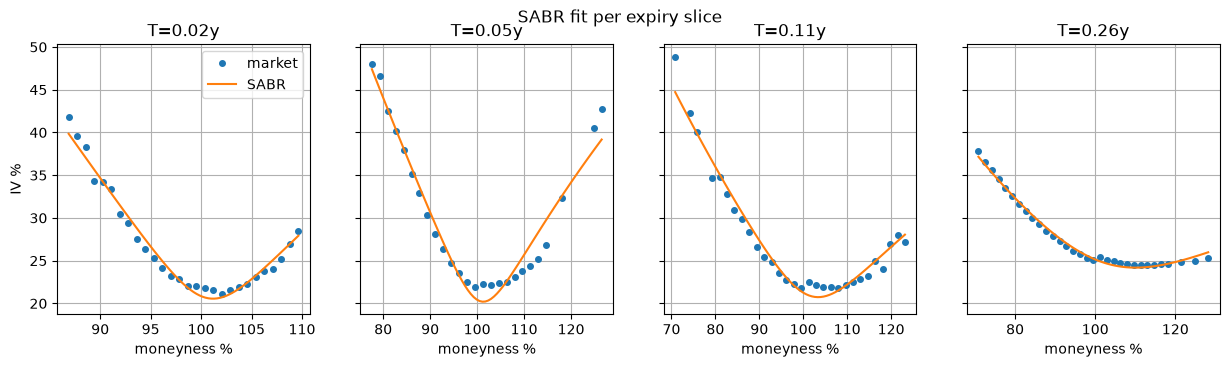

In [15]:
# Market smile vs the calibrated SABR curve, for a few expiries.
ts = sorted(sabr_params)[:4]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 3.5), sharey=True)
for ax, T in zip(np.atleast_1d(axes), ts):
    g = surf[np.isclose(surf["T"], T)].sort_values("moneyness")
    F = g["F"].iloc[0]; p = sabr_params[T]
    kk = np.linspace(g["strike"].min(), g["strike"].max(), 80)
    fit = [sabr_iv(F, K, T, **p) for K in kk]
    ax.plot(g["moneyness"] * 100, g["iv"] * 100, "o", ms=4, label="market")
    ax.plot(kk / S0 * 100, np.array(fit) * 100, "-", label="SABR")
    ax.set_title(f"T={T:.2f}y"); ax.set_xlabel("moneyness %")
axes[0].set_ylabel("IV %"); axes[0].legend(); plt.suptitle("SABR fit per expiry slice"); plt.show()

In [16]:
# Assemble the calibrated slices into a full SABR implied-vol surface.
mm = np.linspace(surf["moneyness"].min(), surf["moneyness"].max(), 40)
Ts = np.array(sorted(sabr_params))
Z = np.zeros((len(Ts), len(mm)))
for i, T in enumerate(Ts):
    F = S0 * np.exp((risk_free_rate(T) - q_div) * T); p = sabr_params[T]
    Z[i] = [sabr_iv(F, m * S0, T, **p) for m in mm]
MMs, TTs = np.meshgrid(mm, Ts)

fig = go.Figure(go.Surface(x=MMs * 100, y=TTs, z=Z * 100, colorscale="Plasma"))
fig.update_layout(height=600, width=850, title=f"{TICKER} calibrated SABR vol surface",
                  scene=dict(xaxis_title="moneyness %", yaxis_title="T (yrs)", zaxis_title="IV %"))
fig.show()

## 9. Heston — stochastic volatility from the ground up

Heston makes **variance itself** a mean-reverting stochastic process:
$$ dS_t = (r-q)S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S,\qquad
   dv_t = \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v,\qquad dW^S dW^v=\rho\,dt. $$

- $v_0$ — current variance; $\theta$ — long-run variance; $\kappa$ — mean-reversion speed.
- $\xi$ — vol-of-vol ⇒ **smile curvature**; $\rho$ — correlation ⇒ **skew** (equities: $\rho<0$).
- *Feller* $2\kappa\theta>\xi^2$ keeps variance positive.

Heston has a **semi-closed-form** price via its characteristic function (no Monte Carlo needed),
which is why it's a workhorse for whole-surface fitting. Per our Week-1 plan we use **illustrative
parameters** here; calibration would minimise $\sum (\sigma^{\text{model}}_i-\sigma^{\text{mkt}}_i)^2$
over $(\kappa,\theta,\xi,\rho,v_0)$ across the *entire* chain at once (vs SABR's per-slice fit).

In [17]:
def heston_cf(phi, S, T, r, q, kappa, theta, xi, rho, v0):
    '''Heston characteristic function of ln(S_T) — 'little trap' form (Albrecher et al.).'''
    x0 = np.log(S)
    a = kappa * theta
    d = np.sqrt((rho * xi * 1j * phi - kappa) ** 2 + (xi ** 2) * (1j * phi + phi ** 2))
    g = (kappa - rho * xi * 1j * phi - d) / (kappa - rho * xi * 1j * phi + d)
    exp_dt = np.exp(-d * T)
    C = (r - q) * 1j * phi * T + (a / xi ** 2) * (
        (kappa - rho * xi * 1j * phi - d) * T - 2 * np.log((1 - g * exp_dt) / (1 - g)))
    D = ((kappa - rho * xi * 1j * phi - d) / xi ** 2) * ((1 - exp_dt) / (1 - g * exp_dt))
    return np.exp(C + D * v0 + 1j * phi * x0)


def heston_call(S, K, T, r, q, kappa, theta, xi, rho, v0, N=4096, umax=200):
    '''European call via the Heston characteristic function (Gil-Pelaez / trapezoid integration).'''
    u = np.linspace(1e-6, umax, N)

    def P(j):  # risk-neutral probabilities P1, P2
        if j == 1:
            cf = heston_cf(u - 1j, S, T, r, q, kappa, theta, xi, rho, v0) / \
                 heston_cf(-1j, S, T, r, q, kappa, theta, xi, rho, v0)
        else:
            cf = heston_cf(u, S, T, r, q, kappa, theta, xi, rho, v0)
        integ = np.real(np.exp(-1j * u * np.log(K)) * cf / (1j * u))
        return 0.5 + np.trapezoid(integ, u) / np.pi

    return S * np.exp(-q * T) * P(1) - K * np.exp(-r * T) * P(2)


# Illustrative equity-style parameters (negative rho => downside skew).
# Chosen so the Feller condition 2*kappa*theta > xi^2 holds (variance stays positive).
HP = dict(kappa=3.0, theta=0.04, xi=0.4, rho=-0.7, v0=0.04)
print("Feller 2*kappa*theta > xi^2 :", 2 * HP["kappa"] * HP["theta"], ">", HP["xi"] ** 2,
      "->", 2 * HP["kappa"] * HP["theta"] > HP["xi"] ** 2)

_c = heston_call(S0, S0, 1.0, float(risk_free_rate(1.0)), q_div, **HP)
print(f"Heston ATM 1y call on {TICKER}: {_c:.2f}")

Feller 2*kappa*theta > xi^2 : 0.24 > 0.16000000000000003 -> True
Heston ATM 1y call on AAPL: 27.92


In [18]:
# Build a Heston implied-vol surface: price on a grid, then invert each price to BS implied vol.
m_grid = np.linspace(0.8, 1.2, 25)
T_grid = np.linspace(0.1, 1.5, 20)
Zh = np.zeros((len(T_grid), len(m_grid)))
for i, T in enumerate(T_grid):
    r = float(risk_free_rate(T))
    for j, m in enumerate(m_grid):
        K = m * S0
        price = heston_call(S0, K, T, r, q_div, **HP)
        Zh[i, j] = implied_vol(price, S0, K, T, r, q_div, "call")
MMh, TTh = np.meshgrid(m_grid, T_grid)

fig = go.Figure(go.Surface(x=MMh * 100, y=TTh, z=Zh * 100, colorscale="Turbo"))
fig.update_layout(height=600, width=850,
                  title="Heston implied-vol surface (illustrative parameters)",
                  scene=dict(xaxis_title="moneyness %", yaxis_title="T (yrs)", zaxis_title="IV %"))
fig.show()

**Read the Heston surface.** Even with *constant* parameters, stochastic vol generates a realistic
shape: $\rho<0$ tilts the smile into a downside **skew**, $\xi$ gives it **curvature**, and the skew
**flattens with maturity** — qualitatively the same features you saw in the live AAPL surface in
Section 5. That's the punchline: a handful of economically meaningful parameters reproduce the entire
market surface, which is exactly why desks price exotics off Heston/SABR rather than a flat BS number.

## 10. Theory → practice: what to take away

| Concept | Theory you knew | What this notebook showed in practice |
|---|---|---|
| Discounting | $e^{-rT}\mathbb{E}^{\mathbb{Q}}$ | a real **term structure** from FRED, interpolated per maturity |
| Realized vol | std of log returns | it **clusters** — never constant — and GARCH forecasts its term structure |
| Implied vol | invert BS | the **common quoting language**; recovered from live OTM quotes |
| The surface | "vol" | a **skewed, term-dependent** object, *not* a single number |
| BS limitation | constant $\sigma$ | a **flat plane** the market visibly departs from |
| SABR | smile model | a fast **per-slice** 3-parameter fit (desk standard for interpolation) |
| Heston | stochastic-vol SDE | a **semi-closed-form** whole-surface model; few params, realistic shape |
| Implied vs realized | — | implied > realized ⇒ the **variance risk premium** sellers earn |

**What real desks add on top** (natural Week-2+ directions):
- Calibrate Heston to the *whole* chain; add **local vol** (Dupire) and check **static no-arbitrage**
  (calendar + butterfly) on the surface.
- Build the discount/forward curve from **OIS/SOFR** and extract forwards via **put–call parity**
  rather than an assumed dividend yield.
- Use the surface to price/risk-manage exotics and compute **vega/vanna/volga** Greeks.